# Supervisor Architecture

In [70]:
from typing_extensions import Annotated, TypedDict
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages

In [71]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [72]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

    user_input : str

    paths = {
        "plan_path" : str,
        "design_path" : str,
    }

    status = {
        "planning" : str,
        "designing" : str
    }

    next_agent : str

    current_stager : str
    completed_stages : list[str]

    canvas : str

In [73]:
from langchain_openai import ChatOpenAI

In [ ]:
llm = ChatOpenAI(
    model = "gpt-4.1-mini",
    temperature = 0.5,
)

In [75]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.types import Command, interrupt
import datetime

In [76]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id" : "2"}}

In [77]:
import sys
from pathlib import Path

# Go up one directory from "testing grounds" to the project root
project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [108]:
import tools

In [110]:
design_tools = [tools.designer.create, tools.designer.append, tools.designer.rewrite, 
                tools.designer.read_design]
plan_tools = [tools.planner.create, tools.planner.append, tools.planner.rewrite, 
              tools.planner.read_plan, tools.planner.summarize_plan, tools.planner.update_plan]

In [111]:
dtcl = llm.bind_tools(tools = design_tools)

def designer(state:State):
    response = dtcl.invoke(state["messages"])
    return {
            "messages": [response]
    }

In [112]:
designer_graph_builder = StateGraph(State)

designer_graph_builder.add_node("designer", designer)
designer_graph_builder.add_node("tools", ToolNode(tools = design_tools))

designer_graph_builder.add_conditional_edges(
    "designer",
    tools_condition
)

designer_graph_builder.add_edge(START, "designer")
designer_graph_builder.add_edge("tools" ,"designer")

design_graph = designer_graph_builder.compile()

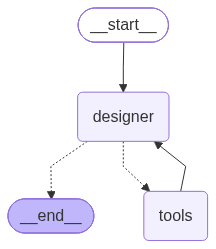

In [113]:
design_graph

In [114]:
ptcl = llm.bind_tools(tools = plan_tools)

def planner(state:State):
    response = ptcl.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [115]:
planner_graph_builder = StateGraph(State)

planner_graph_builder.add_node("planner", planner)
planner_graph_builder.add_node("tools", ToolNode(tools = plan_tools))

planner_graph_builder.add_conditional_edges(
    "planner",
    tools_condition
)

planner_graph_builder.add_edge(START, "planner")
planner_graph_builder.add_edge("tools" ,"planner")

plan_graph = planner_graph_builder.compile()

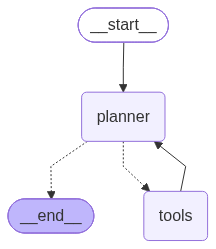

In [116]:
plan_graph

"""
    Use this tool whenever the user requests:

    - project planning
    - requirements gathering
    - milestones
    - task decomposition
    - project roadmap

    Do NOT attempt to create the project plan yourself.

    The Planning Agent is solely responsible for creating and updating plan.md.
    """

In [117]:
from langchain_core.messages import HumanMessage

In [118]:
@tool
def designing_agent(query: str):
    """
        Used for any operation that invovles the design of the application the user is trying to make

        Used to initialize, read, append, rewrite the design in design.md file with respect to:
        -Overall System/Application Architecture
        -Technology Stack Used in Application
        -Main Components
        -Exact logic and description of each module

        DO NOT USE this tools if plan.md is not intialized.

        Args:
            query : a string input which tells the tools what is needed to be done regarding the 
                    design of the application.
        Returns:
                Either confirmation of the design.md file being created, rewritten, appended or 
                the contents of the design.md file
    """
    state = {
        "messages" : [HumanMessage(content = query)]
    }
    result = design_graph.invoke({'messages' : [HumanMessage(content=query)]})
    return result['messages'][-1].content

In [119]:
@tool
def planning_agent(query: str):
    """
        Used for any operation that invovles the plan of the application the user is trying to make
        
        Used to initialize, read, append, rewrite the plan in plan.md file with respect to:
        - project planning
        - requirements gathering
        - milestones
        - task decomposition
        - project roadmap
    
        Args:
            query : a string input which tells the tool what is needed to be done regarding the 
                    design of the application.
        Returns:
            Either confirmation of the plan.md file being created, rewritten, appended, updated or 
            the contents, summary of the design.md file
    """
    state = {
        "messages" : [HumanMessage(content = query)]
    }
    result = plan_graph.invoke({'messages': [HumanMessage(content=query)]})
    return result['messages'][-1].content

In [127]:
orchestrating_tools = [designing_agent, planning_agent]

orchestrator = llm.bind_tools(tools = orchestrating_tools)

def orchs(state:State):
    response = orchestrator.invoke(state['messages'])
    return {"messages": [response]}

orchestrator_graph_builder = StateGraph(State)

orchestrator_graph_builder.add_node("Orchestrator", orchs)
orchestrator_graph_builder.add_node("tools", ToolNode(tools = orchestrating_tools))

orchestrator_graph_builder.add_edge(START, "Orchestrator")
orchestrator_graph_builder.add_conditional_edges(
    "Orchestrator",
    tools_condition
)
orchestrator_graph_builder.add_edge("tools", "Orchestrator")

orchestration = orchestrator_graph_builder.compile()


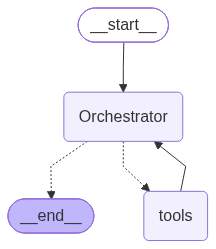

In [128]:
orchestration

In [132]:
prompt = """I want to build a cross-platform hospital management system.

Begin by preparing a comprehensive project plan including functional requirements, non-functional requirements, milestones, risks, assumptions, and task decomposition.

After completing the plan, make the design the software architecture. Include the system architecture, database schema, module interactions, REST API structure, authentication flow, deployment architecture, and UML diagrams.

Do not skip any phase, and complete each phase before moving to the next"""

In [133]:
response = orchestration.invoke({'messages' : [HumanMessage(content=prompt)]})

In [131]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

I want to build a cross-platform hospital management system.

Begin by preparing a comprehensive project plan including functional requirements, non-functional requirements, milestones, risks, assumptions, and task decomposition.

After completing the plan, design the software architecture. Include the system architecture, database schema, module interactions, REST API structure, authentication flow, deployment architecture, and UML diagrams.

Do not skip any phase, and complete each phase before moving to the next
================================== Ai Message ==================================
Tool Calls:
  planning_agent (call_Gx09fnXisxHam1lApcrsrMRn)
 Call ID: call_Gx09fnXisxHam1lApcrsrMRn
  Args:
    query: Initialize a comprehensive project plan for a cross-platform hospital management system including functional requirements, non-functional requirements, milestones, risks, assumptions, and task dec